In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import pearsonr, uniform, randint
from tqdm import tqdm
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import category_encoders as ce
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
pd.set_option('display.max_colwidth', None)

In [2]:
# Load the CSV file
df = pd.read_csv('coffee_analysis.csv')

# List the column names
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['name', 'roaster', 'roast', 'loc_country', 'origin_1', 'origin_2', '100g_USD', 'rating', 'review_date', 'desc_1', 'desc_2', 'desc_3']


In [3]:
summary = pd.DataFrame({
    'Total Values': df.count(),
    'Unique Values': df.nunique()
})

print(summary)

             Total Values  Unique Values
name                 2095           1909
roaster              2095            424
roast                2080              5
loc_country          2095             19
origin_1             2095            614
origin_2             2095            357
100g_USD             2095            473
rating               2095             15
review_date          2095             61
desc_1               2095           2092
desc_2               2095           2029
desc_3               2093           2090


In [4]:
# Check for fully duplicated rows
duplicate_rows = df[df.duplicated()]

# Show the duplicated rows
print(duplicate_rows)

# Count how many full duplicates exist
print(f"\nNumber of fully duplicated rows: {duplicate_rows.shape[0]}")

Empty DataFrame
Columns: [name, roaster, roast, loc_country, origin_1, origin_2, 100g_USD, rating, review_date, desc_1, desc_2, desc_3]
Index: []

Number of fully duplicated rows: 0


In [5]:
missing_values = df.isnull().sum()

# Display columns with at least one missing value
print("Missing values per column:")
print(missing_values[missing_values > 0])

Missing values per column:
roast     15
desc_3     2
dtype: int64


In [6]:
df = df.dropna(subset=['roast'])

In [7]:
# Create a new 'origin' column by merging 'origin_1' and 'origin_2'
df['origin'] = df['origin_1'].fillna('') + ' ' + df['origin_2'].fillna('')


In [8]:
sns.set(style='whitegrid')

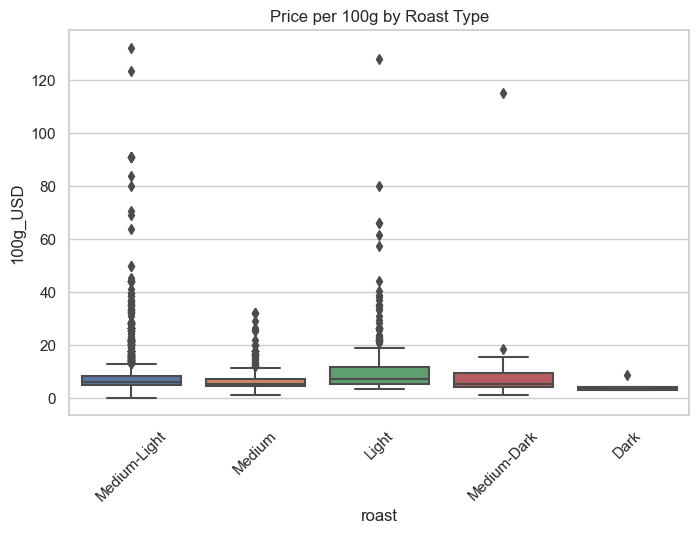

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='roast', y='100g_USD', data=df)
plt.title('Price per 100g by Roast Type')
plt.xticks(rotation=45)
plt.show()

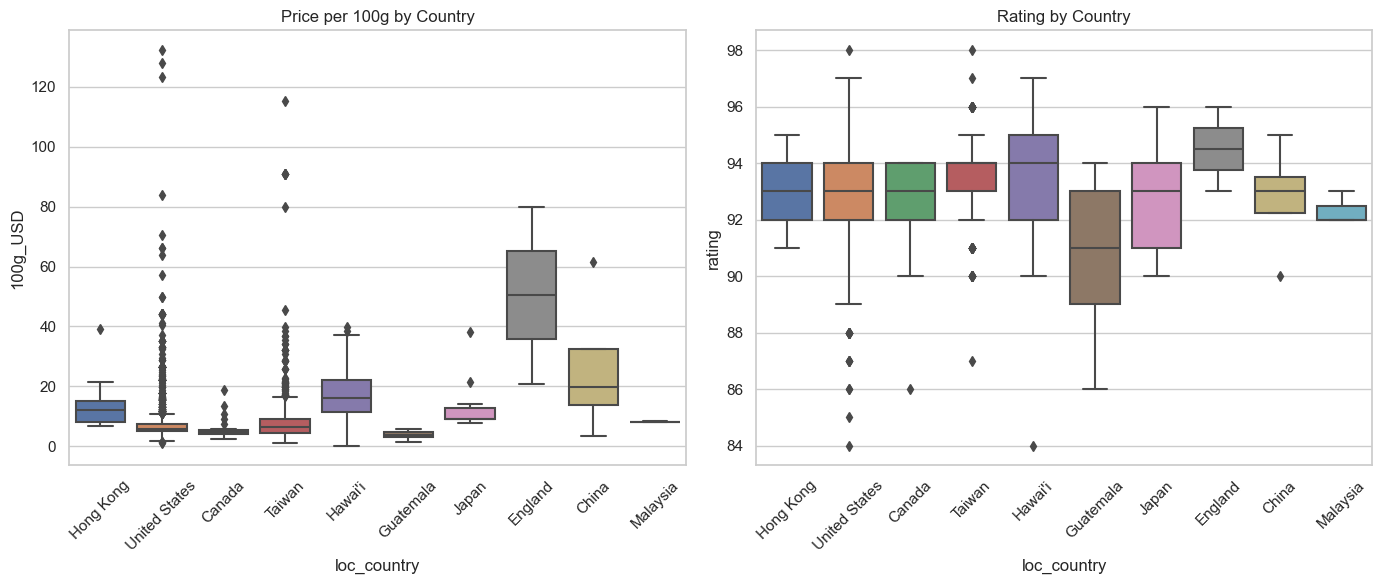

In [10]:
top_countries = df['loc_country'].value_counts().head(10).index
df_top = df[df['loc_country'].isin(top_countries)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(x='loc_country', y='100g_USD', data=df_top, ax=axes[0])
axes[0].set_title('Price per 100g by Country')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='loc_country', y='rating', data=df_top, ax=axes[1])
axes[1].set_title('Rating by Country')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

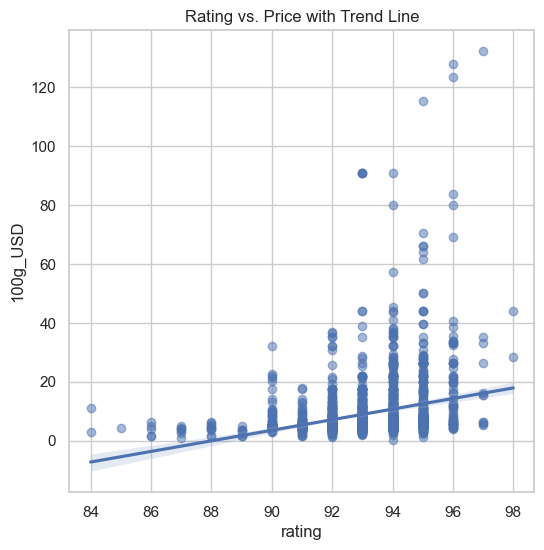

In [11]:
plt.figure(figsize=(6, 6))
sns.regplot(x='rating', y='100g_USD', data=df, scatter_kws={'alpha':0.5})
plt.title('Rating vs. Price with Trend Line')
plt.show()

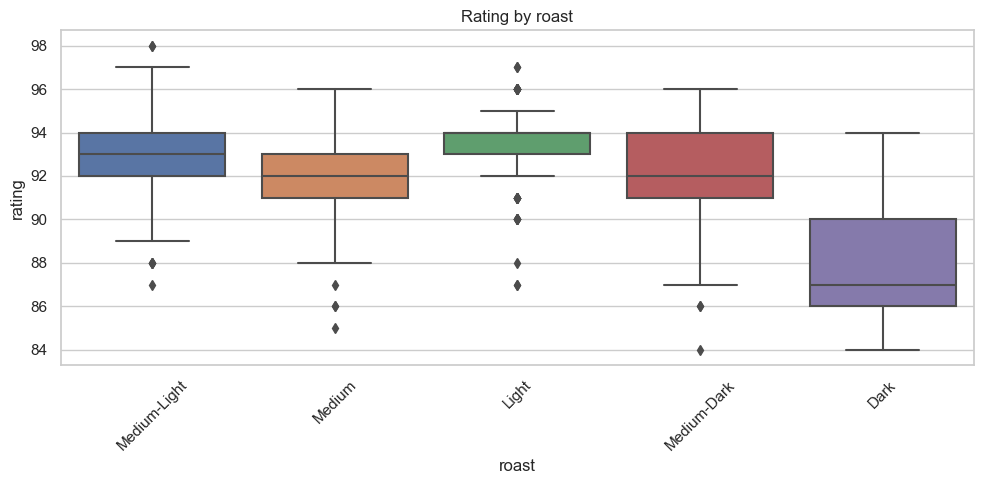

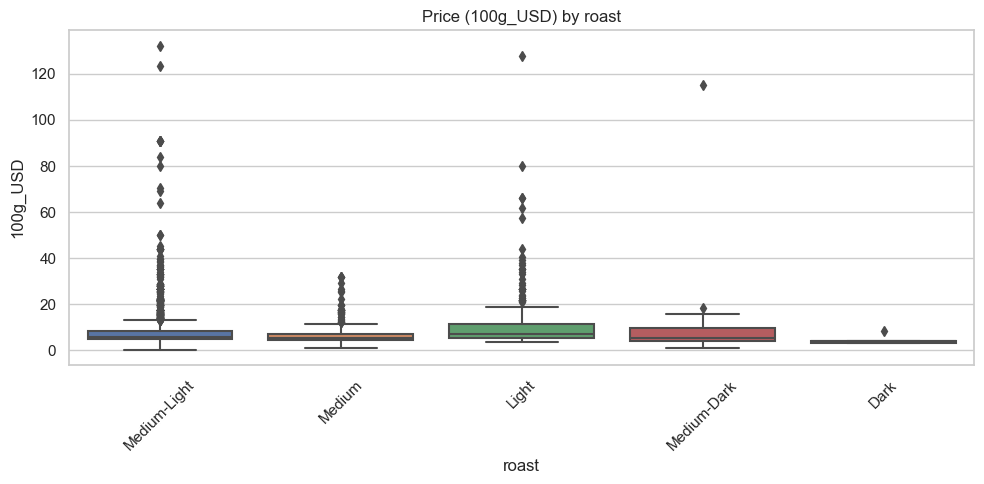

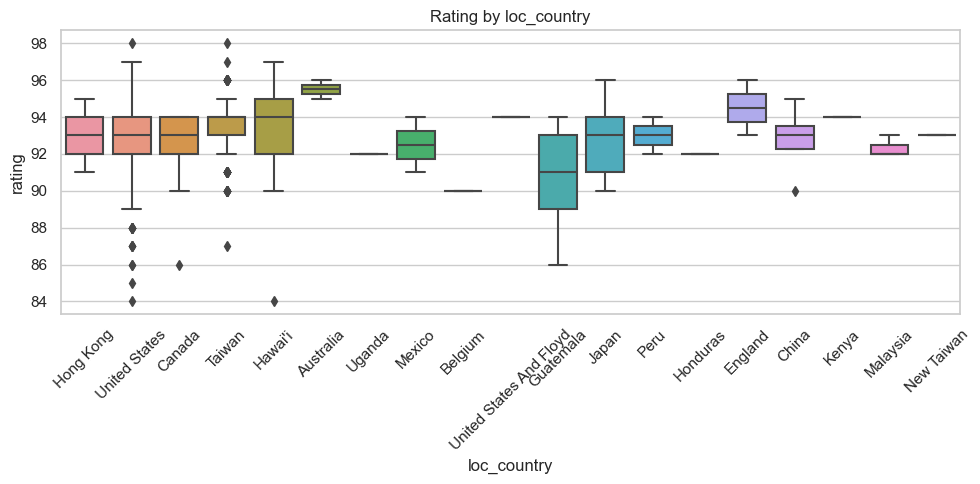

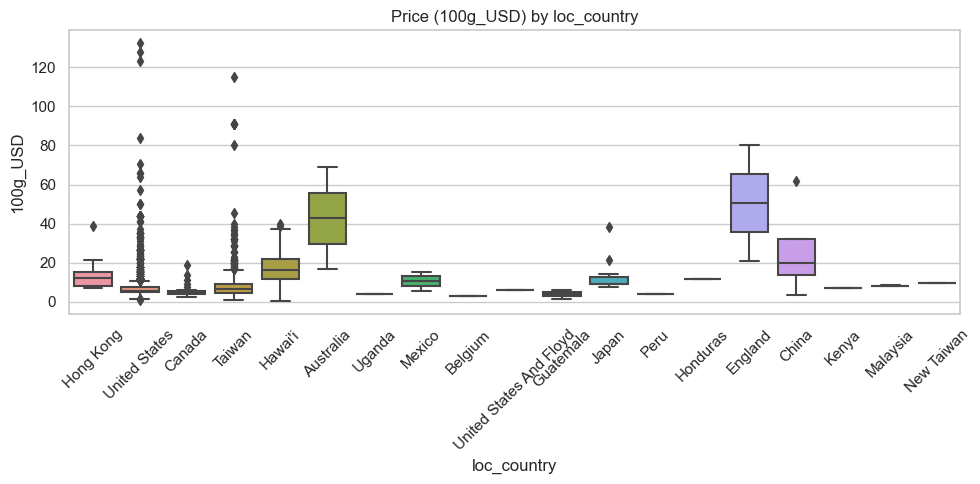

In [12]:
# 2. roast and loc_country 
for col in ['roast', 'loc_country']:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=col, y='rating', data=df)
    plt.title(f'Rating by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.boxplot(x=col, y='100g_USD', data=df)
    plt.title(f'Price (100g_USD) by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

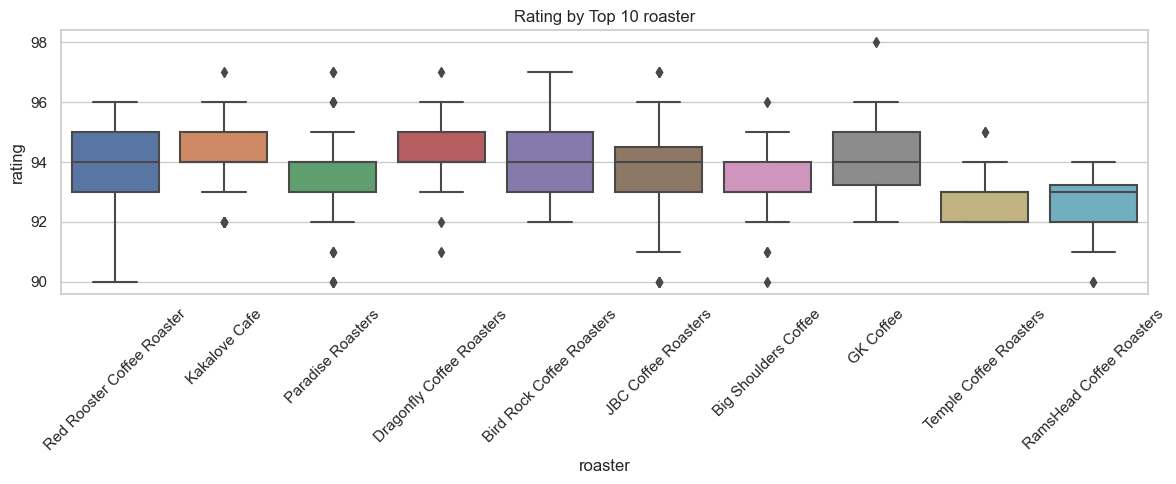

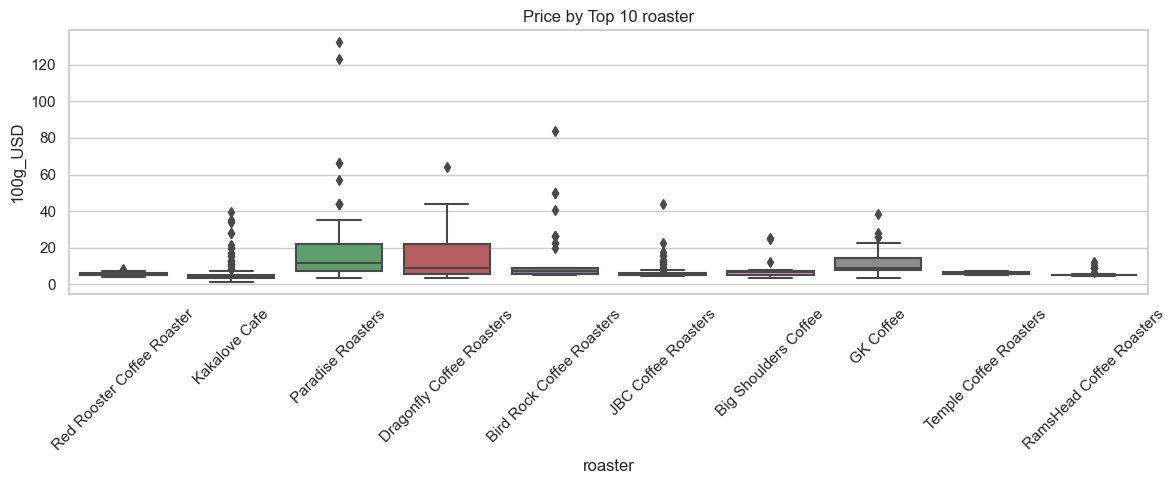

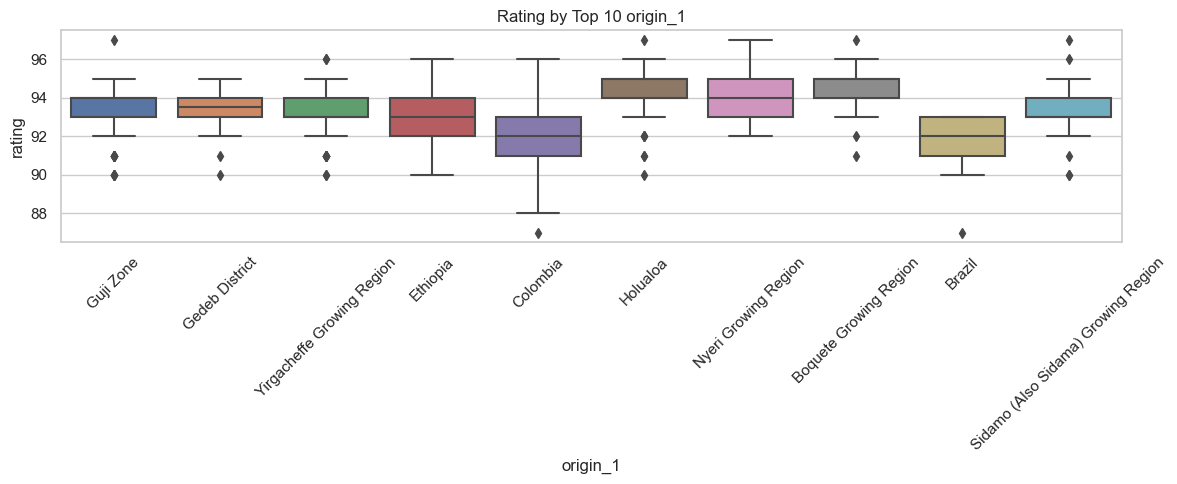

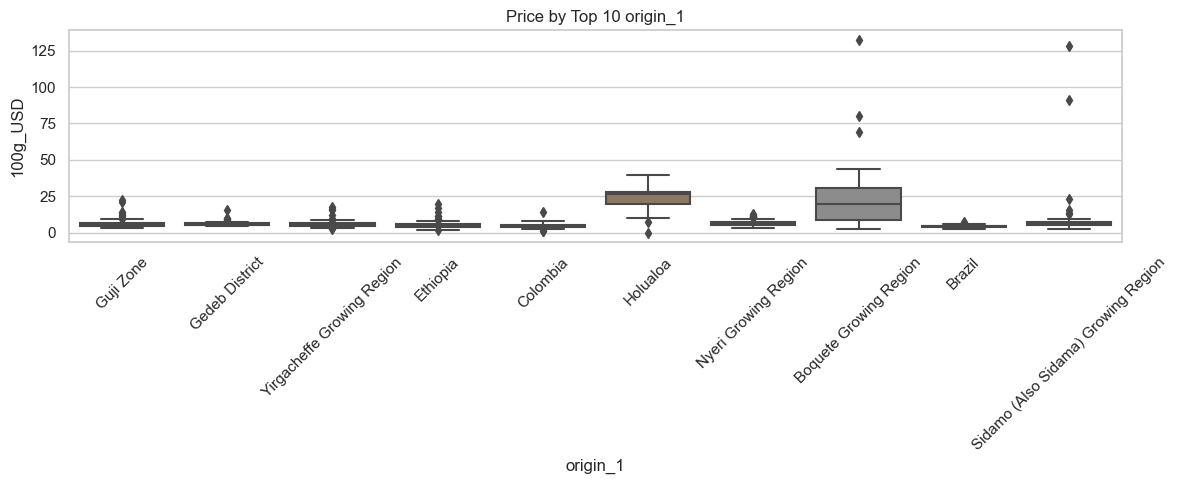

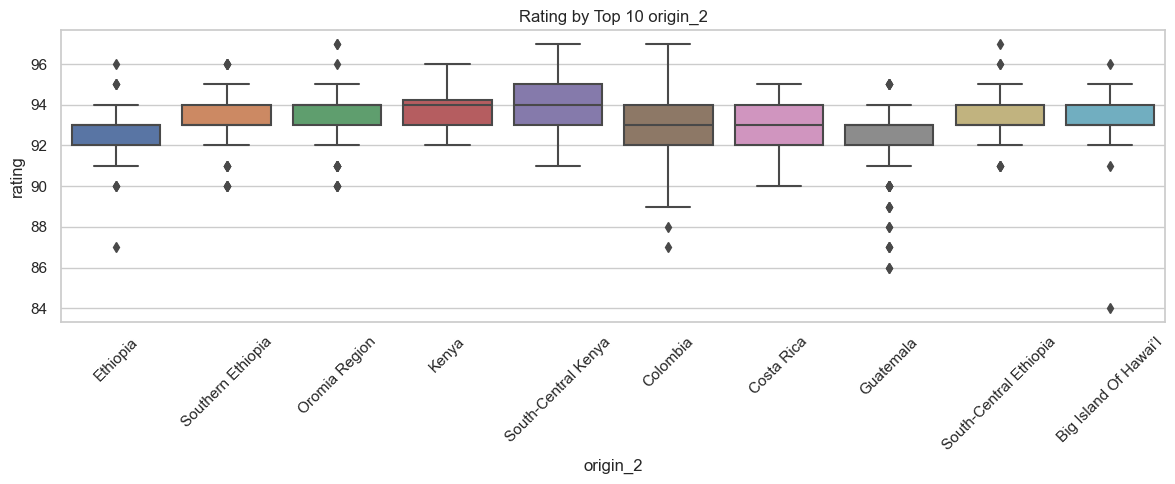

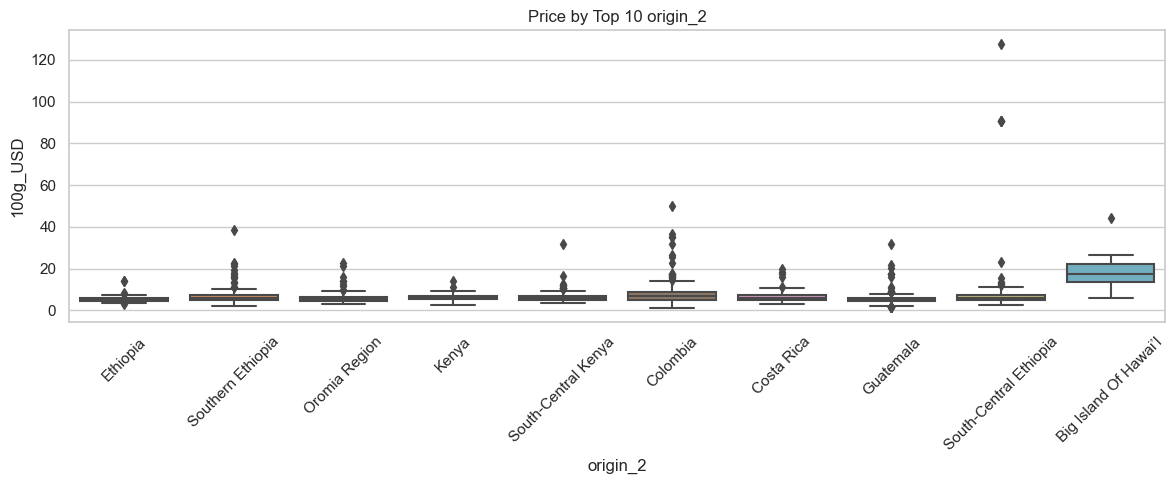

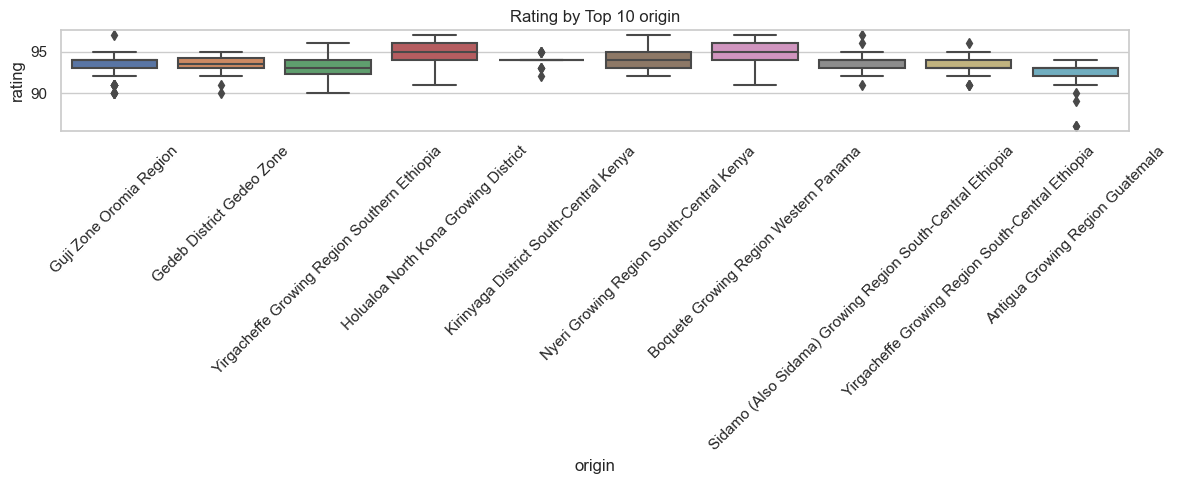

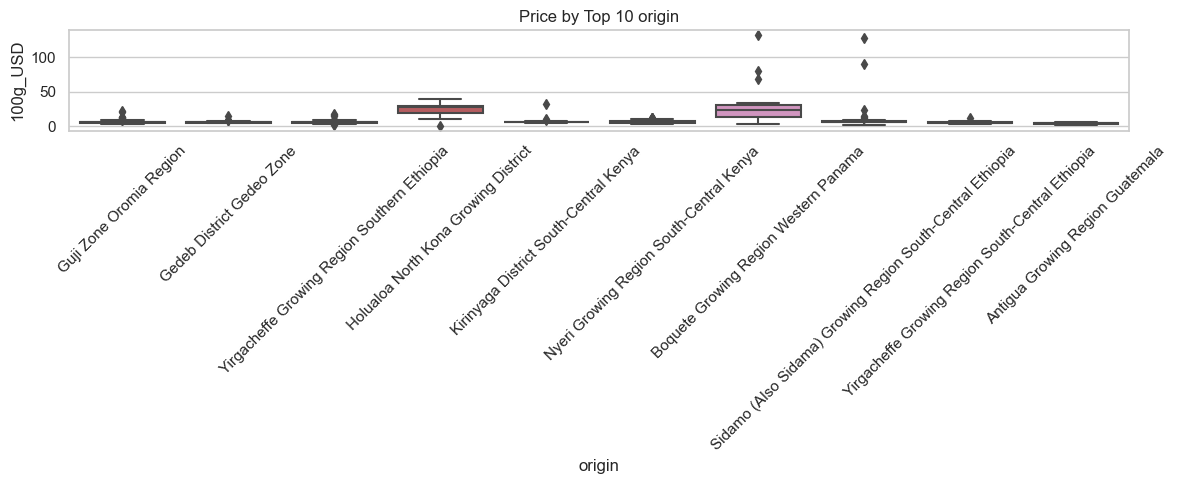

In [13]:
# 3. High-cardinality: Use Top 10 most common values
high_card_cols = ['roaster', 'origin_1', 'origin_2', 'origin']
for col in high_card_cols:
    top_10 = df[col].value_counts().nlargest(10).index
    plt.figure(figsize=(12, 5))
    sns.boxplot(x=col, y='rating', data=df[df[col].isin(top_10)])
    plt.title(f'Rating by Top 10 {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    sns.boxplot(x=col, y='100g_USD', data=df[df[col].isin(top_10)])
    plt.title(f'Price by Top 10 {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [14]:
# Combine the 3 description columns into one
df['full_desc'] = df[['desc_1', 'desc_2', 'desc_3']].fillna('').agg(' '.join, axis=1)

# Drop the original description columns
df.drop(columns=['desc_1', 'desc_2', 'desc_3'], inplace=True)

In [15]:
def clean_text(text_series):
    """Lowercase and remove non-letter characters from text."""
    return (
        text_series.fillna('')
        .str.lower()
        .apply(lambda x: re.sub(r'[^a-z\s]', '', x))
    )

def get_significant_ngrams(df, text_col='full_desc', min_df=2, ngram_range=(1, 4), max_features=10000):
    # Clean the text
    text_clean = clean_text(df[text_col])

    # Vectorize
    vectorizer = CountVectorizer(
        min_df=min_df,
        ngram_range=ngram_range,
        stop_words='english',
        max_features=max_features
    )
    X_ngrams = vectorizer.fit_transform(text_clean)
    feature_names = vectorizer.get_feature_names_out()

    price_array = df['100g_USD'].values
    rating_array = df['rating'].values

    data = []

    print("🔄 Calculating correlations and p-values...")
    for i in tqdm(range(X_ngrams.shape[1])):
        col = X_ngrams.getcol(i).toarray().flatten()
        try:
            corr_price, pval_price = pearsonr(col, price_array)
            corr_rating, pval_rating = pearsonr(col, rating_array)
        except Exception:
            corr_price, pval_price = 0, 1
            corr_rating, pval_rating = 0, 1

        data.append({
            "phrase": feature_names[i],
            "corr_with_price": corr_price,
            "pval_price": pval_price,
            "corr_with_rating": corr_rating,
            "pval_rating": pval_rating,
            "combined_corr": abs(corr_price) + abs(corr_rating)
        })

    results_df = pd.DataFrame(data)
    return results_df

# 🔍 Run the analysis
results = get_significant_ngrams(df, text_col='full_desc', min_df=2, ngram_range=(1, 4), max_features=10000)

# 🧠 Show top phrases by combined correlation
top_phrases = {
    "Top Price ↑": results.sort_values("corr_with_price", ascending=False).head(8),
    "Top Rating ↑": results.sort_values("corr_with_rating", ascending=False).head(8),
    "Low Price ↓": results.sort_values("corr_with_price", ascending=True).head(8),
    "Low Rating ↓": results.sort_values("corr_with_rating", ascending=True).head(8),
}

# 📋 Print out the top phrases with correlations and p-values
for category, df_cat in top_phrases.items():
    print(f"\n📌 {category}")
    print(df_cat[['phrase', 'corr_with_price', 'pval_price', 'corr_with_rating', 'pval_rating']])

🔄 Calculating correlations and p-values...


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:40<00:00, 248.12it/s]


📌 Top Price ↑
                                    phrase  corr_with_price    pval_price  \
1108                                   cat         0.388264  8.342790e-76   
1428                             civet cat         0.388264  8.342790e-76   
5376                                 luwak         0.381986  3.091366e-73   
1427                                 civet         0.380401  1.349176e-72   
9279                               variety         0.350489  3.583900e-61   
4078                                geisha         0.341171  7.403688e-58   
2074                   company information         0.307676  7.552042e-47   
8271  specialty coffee company information         0.307676  7.552042e-47   

      corr_with_rating   pval_rating  
1108          0.002791  8.987660e-01  
1428          0.002791  8.987660e-01  
5376          0.002185  9.206801e-01  
1427          0.004272  8.456164e-01  
9279          0.174487  1.104722e-15  
4078          0.172776  2.108483e-15  
2074          0.00

In [16]:
price_phrases = [
    'capsule', 'nespresso capsule', 'geisha',
    'worlds celebrated', 'soughtafter coffee varieties'
]

rating_phrases = [
    'juicy', 'geisha', 'celebrated',
    'velvety mouthfeel', 'brisk acidity'
]

# Create vectorizers
vectorizer_price = CountVectorizer(
    vocabulary=price_phrases, binary=True, lowercase=True, ngram_range=(1, 4)
)
vectorizer_rating = CountVectorizer(
    vocabulary=rating_phrases, binary=True, lowercase=True, ngram_range=(1, 4)
)

# Clean and transform text
desc = df['full_desc'].fillna('')

X_price = vectorizer_price.transform(desc)
X_rating = vectorizer_rating.transform(desc)

# Convert to DataFrames
price_features = pd.DataFrame(
    X_price.toarray(),
    columns=vectorizer_price.get_feature_names_out(),
    index=df.index
)
rating_features = pd.DataFrame(
    X_rating.toarray(),
    columns=vectorizer_rating.get_feature_names_out(),
    index=df.index
)

# 🔁 Merge features with original DataFrame
df_price = pd.concat([df.copy(), price_features], axis=1)
df_rating = pd.concat([df.copy(), rating_features], axis=1)

In [17]:
# Target encode high-cardinality categorical features
def encode_target_features(df, y_col):
    high_card_cat = [
        col for col in df.select_dtypes(include=['object', 'category'])
        if df[col].nunique() > 50
    ]
    encoder = ce.TargetEncoder(cols=high_card_cat)
    df[high_card_cat] = encoder.fit_transform(df[high_card_cat], df[y_col])
    return df

In [18]:
cols_to_remove = ['name', 'full_desc', 'review_date']

df_price = df_price.drop(columns=cols_to_remove, errors='ignore')
df_rating = df_rating.drop(columns=cols_to_remove, errors='ignore')

In [ ]:
# === Define models and hyperparameter grids === #
model_classes = {
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0)
}

param_grids = {
    "Lasso": {"alpha": uniform(0.0001, 1)},
    "Ridge": {"alpha": uniform(0.1, 10)},
    "Random Forest": {
        "n_estimators": randint(50, 200),
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "Gradient Boosting": {
        "n_estimators": randint(50, 200),
        "learning_rate": uniform(0.01, 0.3),
        "max_depth": [3, 5, 7]
    },
    "XGBoost": {
        "n_estimators": randint(50, 200),
        "learning_rate": uniform(0.01, 0.3),
        "max_depth": [3, 5, 7],
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4)
    }
}

# === Evaluation === #
def evaluate_model(model, X_train, X_test, y_train, y_test, name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
 #   print(f"{name:<20} | RMSE: {rmse:.3f} | R²: {r2:.3f}")
    return rmse, r2

# === Tuning === #
def tune_model(model, X_train, y_train, param_grid):
    search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=20,
        cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_

def run_pipeline(df, label):
    results = []

    df_copy = encode_target_features(df.copy(), y_col='100g_USD')
    df_encoded = pd.get_dummies(df_copy, columns=['roast', 'loc_country'], drop_first=True)
    feature_cols = [col for col in df_encoded.columns if col not in ['100g_USD', 'rating']]
    X = df_encoded[feature_cols]
    y = df_encoded['100g_USD']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    for name, model in model_classes.items():
        model.fit(X_train, y_train)

        # Feature selection
        if name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
            importances = model.feature_importances_
            threshold = np.mean(importances)
            selected_features = X.columns[np.where(importances > threshold)].tolist()
        elif name in ["Lasso", "Ridge"]:
            coefs = model.coef_
            threshold = np.mean(np.abs(coefs))
            selected_features = X.columns[np.where(np.abs(coefs) > threshold)].tolist()
        else:
            selected_features = X.columns.tolist()

        if not selected_features:
            continue

        X_train_sel = X_train[selected_features]
        X_test_sel = X_test[selected_features]

        tuned_model, best_params = tune_model(model_classes[name], X_train_sel, y_train, param_grids[name])
        rmse, r2 = evaluate_model(tuned_model, X_train_sel, X_test_sel, y_train, y_test)

        results.append({
            "Model": name,
            "RMSE": round(rmse, 3),
            "R2": round(r2, 3),
            "Best Params": str({k: round(v, 3) if isinstance(v, (float, int)) else v for k, v in best_params.items()}),
            "Selected Features": f"{len(selected_features)}: {', '.join(selected_features)}"
        })

    return pd.DataFrame(results)


In [35]:
price_results_df = run_pipeline(df_price, "Price Phrases")
rating_results_df = run_pipeline(df_rating, "Rating Phrases")

# Sort by RMSE (ascending: best model first)
price_results_df_sorted = price_results_df.sort_values(by="RMSE")
rating_results_df_sorted = rating_results_df.sort_values(by="RMSE")

# 1. Show summary of all models: RMSE + R² only
print("\n📊 Price Phrase Model Summary:")
display(price_results_df_sorted[["Model", "RMSE", "R2"]])

print("\n📊 Rating Phrase Model Summary:")
display(rating_results_df_sorted[["Model", "RMSE", "R2"]])

# 2. Show full details for best model only
print("\n🏆 Best Price Phrase Model Details:")
display(price_results_df_sorted.iloc[[0]][["Model", "RMSE", "R2", "Best Params", "Selected Features"]])

print("\n🏆 Best Rating Phrase Model Details:")
display(rating_results_df_sorted.iloc[[0]][["Model", "RMSE", "R2", "Best Params", "Selected Features"]])


📊 Price Phrase Model Summary:


,Model,RMSE,R2
4,XGBoost,5.082,0.674
3,Gradient Boosting,5.231,0.655
2,Random Forest,5.502,0.618
0,Lasso,7.294,0.329
1,Ridge,7.660,0.260



📊 Rating Phrase Model Summary:


,Model,RMSE,R2
4,XGBoost,4.967,0.689
3,Gradient Boosting,5.312,0.644
2,Random Forest,5.502,0.618
0,Lasso,7.294,0.329
1,Ridge,7.705,0.251



🏆 Best Price Phrase Model Details:


,Model,RMSE,R2,Best Params,Selected Features
4,XGBoost,5.082,0.674,"{'colsample_bytree': 0.944, 'learning_rate': 0.214, 'max_depth': 3, 'n_estimators': 67, 'subsample': 0.98}","5: roaster, origin, geisha, loc_country_England, loc_country_Hawai'i"



🏆 Best Rating Phrase Model Details:


,Model,RMSE,R2,Best Params,Selected Features
4,XGBoost,4.967,0.689,"{'colsample_bytree': 0.657, 'learning_rate': 0.205, 'max_depth': 3, 'n_estimators': 51, 'subsample': 0.889}","8: roaster, origin, geisha, celebrated, roast_Light, loc_country_England, loc_country_Hawai'i, loc_country_Taiwan"
